In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
##Load Engineered Data
X = np.load("X.npy")
y = np.load("y.npy")

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (7691, 30, 7)
y shape: (7691, 7)


In [3]:
##Train / Validation Split (Temporal)
split = int(0.8 * len(X))

X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

print("Train samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])


Train samples: 6152
Validation samples: 1539


In [4]:
##Define Feature Count
TIMESTEPS = X.shape[1]
FEATURES = X.shape[2]


In [5]:
##LSTM Forecasting Model
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(TIMESTEPS, FEATURES)),
    LSTM(32),
    Dense(FEATURES)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

lstm_model.summary()


D:\hyperscale\hyperscale_data_center\ai_models\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 30, 64)              │          18,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 7)                   │             231 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,079 (121.40 KB)

 Trainable params: 31,079 (121.40 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
##Training LSTM Model
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - loss: 0.0871 - val_loss: 0.0727
Epoch 2/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0716 - val_loss: 0.0720
Epoch 3/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0713 - val_loss: 0.0718
Epoch 4/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0715 - val_loss: 0.0718
Epoch 5/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0715 - val_loss: 0.0722
Epoch 6/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.0713 - val_loss: 0.0725
Epoch 7/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.0712 - val_loss: 0.0720
Epoch 8/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0712 - val_loss: 0.0720
Epoch 9/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.0713 - val_loss: 0.0719


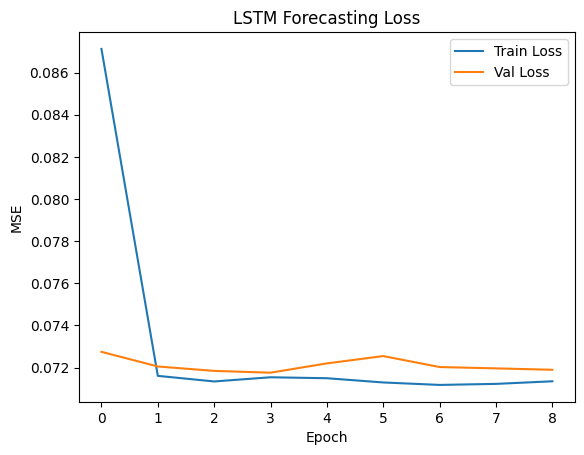

In [7]:
## Plot Training Loss
plt.plot(history_lstm.history["loss"], label="Train Loss")
plt.plot(history_lstm.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("LSTM Forecasting Loss")
plt.legend()
plt.show()


In [8]:
val_loss = lstm_model.evaluate(X_val, y_val, verbose=0)
print("Validation MSE:", val_loss)


Validation MSE: 0.07175557315349579


In [9]:
sample = X_val[-1:]
prediction = lstm_model.predict(sample)

print("Predicted next step:")
print(prediction[0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step
Predicted next step:
[0.5083848  0.52001375 0.51267844 0.5038871  0.509384   0.50637287
 0.52521026]


In [10]:
lstm_model.save("lstm_forecasting_model.h5")


In [11]:
gru_model = Sequential([
    GRU(64, return_sequences=True, input_shape=(TIMESTEPS, FEATURES)),
    GRU(32),
    Dense(FEATURES)
])

gru_model.compile(
    optimizer="adam",
    loss="mse"
)

gru_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 30, 64)              │          14,016 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 32)                  │           9,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 7)                   │             231 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,655 (92.40 KB)

 Trainable params: 23,655 (92.40 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history_gru = gru_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - loss: 0.0873 - val_loss: 0.0730
Epoch 2/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.0721 - val_loss: 0.0727
Epoch 3/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.0718 - val_loss: 0.0722
Epoch 4/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.0714 - val_loss: 0.0722
Epoch 5/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.0715 - val_loss: 0.0722


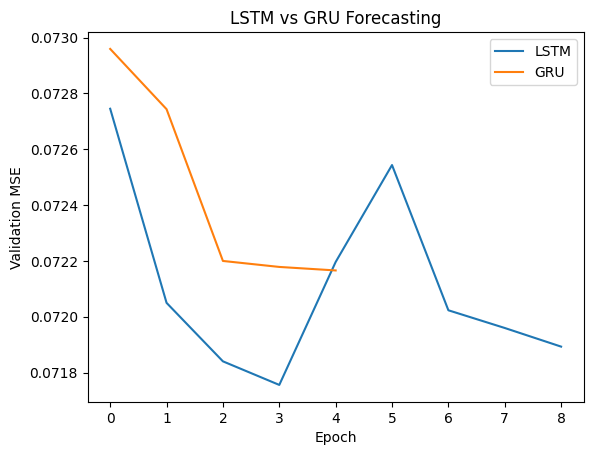

In [13]:
plt.plot(history_lstm.history["val_loss"], label="LSTM")
plt.plot(history_gru.history["val_loss"], label="GRU")
plt.xlabel("Epoch")
plt.ylabel("Validation MSE")
plt.title("LSTM vs GRU Forecasting")
plt.legend()
plt.show()


In [14]:
gru_model.save("gru_forecasting_model.h5")


In [15]:
##Multivariate LSTM and GRU models were trained to forecast next-step energy consumption and thermal states of data-center racks using sliding-window telemetry sequences.”

In [16]:
import numpy as np

TIME_STEPS = X_val.shape[1]
NUM_FEATURES = X_val.shape[2]
FORECAST_HOURS = 24

current_window = X_val[-1].copy()  # shape: (time_steps, features)



In [17]:
forecast_24h = []

for step in range(FORECAST_HOURS):
    input_batch = current_window.reshape(1, TIME_STEPS, NUM_FEATURES)

    next_step = lstm_model.predict(input_batch, verbose=0)[0]
    forecast_24h.append(next_step)

    # Shift window left
    current_window = np.roll(current_window, -1, axis=0)

    # Insert prediction at last timestep
    current_window[-1, :] = next_step


In [18]:
forecast_24h = np.array(forecast_24h)
print("24-hour forecast shape:", forecast_24h.shape)


24-hour forecast shape: (24, 7)


In [23]:
import pandas as pd
FEATURE_COLUMNS = [
    "power_kw",
    "cpu_util",
    "ambient_temp_c",
    "inlet_temp_c",
    "exhaust_temp_c",
    "fan_speed_rpm",
    "humidity"
]


forecast_df = pd.DataFrame(
    forecast_24h,
    columns=FEATURE_COLUMNS
)

forecast_df.to_csv("forecast_next_24_hours.csv", index=False)
print("Forecast saved successfully")




Forecast saved successfully


In [27]:
forecast_power_kw = forecast_24h[:, 0]
MAX_RACK_POWER_KW = 250
MAX_DC_POWER_MW = 4.2
RACK_COUNT = 4
dc_power_mw = (forecast_power_kw * RACK_COUNT) / 1000

rack_risk = forecast_power_kw > MAX_RACK_POWER_KW
dc_risk = dc_power_mw > MAX_DC_POWER_MW
risk_table = pd.DataFrame({
    "Hour_Ahead": np.arange(1, 25),
    "Forecast_Rack_Power_kW": np.round(forecast_power_kw, 2),
    "Rack_Limit_kW": MAX_RACK_POWER_KW,
    "Rack_Risk": np.where(rack_risk, "YES", "NO"),
    "Forecast_DC_Power_MW": np.round(dc_power_mw, 2),
    "DC_Limit_MW": MAX_DC_POWER_MW,
    "DC_Risk": np.where(dc_risk, "YES", "NO")
})

def risk_severity(row):
    if row["DC_Risk"] == "YES":
        return "CRITICAL"
    elif row["Rack_Risk"] == "YES":
        return "WARNING"
    else:
        return "SAFE"

risk_table["Severity"] = risk_table.apply(risk_severity, axis=1)
risk_table


,Hour_Ahead,Forecast_Rack_Power_kW,Rack_Limit_kW,Rack_Risk,Forecast_DC_Power_MW,DC_Limit_MW,DC_Risk,Severity
0,1,0.51,250,NO,0.0,4.2,NO,SAFE
1,2,0.51,250,NO,0.0,4.2,NO,SAFE
2,3,0.51,250,NO,0.0,4.2,NO,SAFE
3,4,0.51,250,NO,0.0,4.2,NO,SAFE
4,5,0.51,250,NO,0.0,4.2,NO,SAFE
5,6,0.51,250,NO,0.0,4.2,NO,SAFE
6,7,0.51,250,NO,0.0,4.2,NO,SAFE
7,8,0.51,250,NO,0.0,4.2,NO,SAFE
8,9,0.51,250,NO,0.0,4.2,NO,SAFE
9,10,0.51,250,NO,0.0,4.2,NO,SAFE
